# Superdense Coding

Mirroring quantum teleportation which transmits 1 qubit using a Bell pair and 2 classical bits, superdense coding sends 2 classical bits using a Bell pair through a quantum channel.

Alice and Bob initially share the Bell state $|B_{00}\rangle$, where $|B_{00}\rangle = \frac{1}{\sqrt{2}}(|00\rangle+|11\rangle)$, $|B_{01}\rangle = \frac{1}{\sqrt{2}}(|10\rangle+|01\rangle)$, $|B_{10}\rangle = \frac{1}{\sqrt{2}}(|00\rangle-|11\rangle)$, and $|B_{11}\rangle=\frac{1}{\sqrt{2}}(|01\rangle-|10\rangle)$. Alice applies a sequence of gates according to the message she is sending. Then she sends her qubit to Bob who measures both qubits in the Bell basis, from which he is able to determine the classical bits Alice wished to send. For $00$, Alice sends her qubit as is and Bob measures $|B_{00}\rangle$. For $01$, Alice applies an $\hat X$ gate and Bob measures $|B_{01}\rangle$. For $10$, Alice applies a $\hat Z$ gate and Bob measures $|B_{10}\rangle$. For $11$, Alice applies an $\hat X$ gate then a $\hat Z$ gate and Bob measures $|B_{11}\rangle$.

In [13]:
#imports
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.primitives import StatevectorSampler
from IPython.display import display

In [14]:
def make_bell_state():
    qc = QuantumCircuit(2)
    qc.h(0)
    qc.cx(0,1)
    return qc

In [15]:
def encode(bits, qc):
    assert isinstance(bits, str)
    assert len(bits) == 2
    assert isinstance(qc, QuantumCircuit)
    assert qc.num_qubits == 2
    b0, b1 = int(bits[0]), int(bits[1])
    if b1 == 1:
        qc.x(0)
    if b0 == 1:
        qc.z(0)
    print("Qubit encoded:")
    display(Statevector(qc).draw('latex'))

In [16]:
def decode(qc):
    assert isinstance(qc, QuantumCircuit)
    assert qc.num_qubits == 2
    qc.cx(0,1)
    qc.h(0)
    qc.measure_all() #Bell measurement - bell basis rotated to computational basis
    sampler = StatevectorSampler()
    result = sampler.run([qc], shots = 1000).result() #deterministic
    counts = result[0].data.meas.get_counts()
    print(f"Bit decoded: {max(counts, key=counts.get)[::-1]}") #reversed bc qiskit orders opposite

In [17]:
def superdense_coding_protocol(bits):
    qc = make_bell_state()
    encode(bits, qc)
    decode(qc)
    display(qc.draw('mpl'))


00
Qubit encoded:


<IPython.core.display.Latex object>

Bit decoded: 00


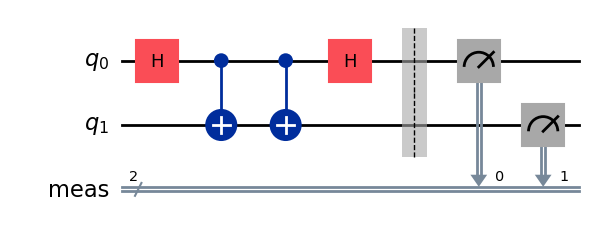


01
Qubit encoded:


<IPython.core.display.Latex object>

Bit decoded: 01


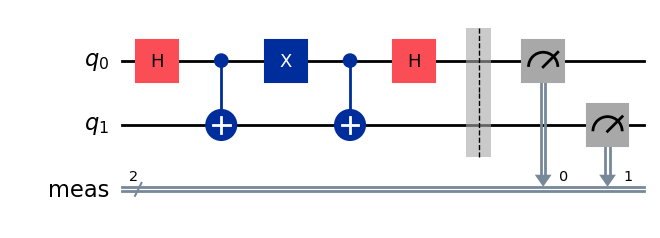


10
Qubit encoded:


<IPython.core.display.Latex object>

Bit decoded: 10


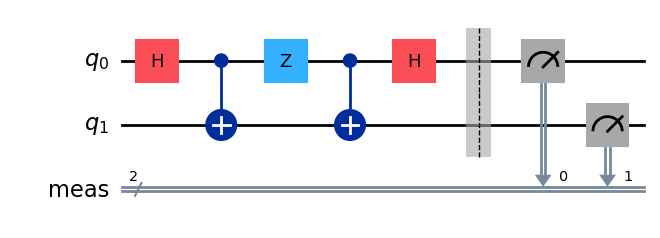


11
Qubit encoded:


<IPython.core.display.Latex object>

Bit decoded: 11


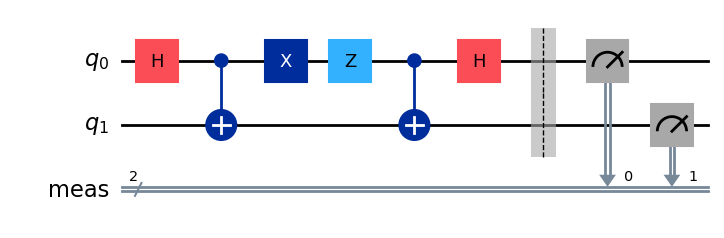

In [18]:
bitstrings = ['00', '01', '10', '11']
for bits in bitstrings:
    print(bits)
    superdense_coding_protocol(bits)
    print("")